In [34]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from tensorflow import keras
from tensorflow.keras.layers import Dense,Input , Flatten , Dropout , BatchNormalization , ReLU, Conv2D, MaxPool2D, GlobalAvgPool2D , RandomFlip , RandomZoom , SpatialDropout2D,RandomRotation, GlobalAveragePooling2D, Rescaling, Activation
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam , SGD
from tensorflow.keras.regularizers import l2 , l1
from tensorflow.keras.datasets import mnist , fashion_mnist
from tensorflow.keras.callbacks import EarlyStopping , ReduceLROnPlateau, ModelCheckpoint


from tensorflow.keras.losses import categorical_crossentropy, binary_crossentropy, binary_focal_crossentropy,categorical_focal_crossentropy
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,LabelEncoder,OneHotEncoder
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay, RocCurveDisplay, roc_auc_score, roc_curve,auc
from sklearn.utils.class_weight import compute_class_weight
from sklearn.datasets import load_iris , make_classification
from tensorflow.keras.utils import to_categorical , image_dataset_from_directory
import os

In [35]:

train_path = '/kaggle/input/datasets/moltean/fruits/fruits-360_100x100/fruits-360/Training'
test_path = '/kaggle/input/datasets/moltean/fruits/fruits-360_100x100/fruits-360/Test'

In [47]:
image_size = (100,100)
BATCH_SIZE = 64

train_ds = image_dataset_from_directory(
    train_path,
    image_size=image_size,

    shuffle=True,
    seed=123,
    validation_split=0.2,
    subset="training",
    batch_size=BATCH_SIZE,
    label_mode = "int"
)

val_ds = image_dataset_from_directory(
    train_path,
    image_size=image_size,
    shuffle=True,
    seed=123,
    validation_split=0.2,
    subset="validation",
    batch_size=BATCH_SIZE,
    label_mode = "int"
)

test_ds = image_dataset_from_directory(
    test_path,
    image_size=image_size,
    batch_size=BATCH_SIZE,
    label_mode = "int"

)

classes = train_ds.class_names

num_of_classes = len(classes)
print(num_of_classes)

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

Found 137221 files belonging to 260 classes.
Using 109777 files for training.
Found 137221 files belonging to 260 classes.
Using 27444 files for validation.
Found 45724 files belonging to 260 classes.
260


In [40]:
data_augmentation = Sequential([
  RandomFlip('horizontal'),
  RandomRotation(0.2),
  RandomZoom(0.2),
])


In [41]:
input = Input(shape=(100,100,3))

x = Rescaling(1./255)(input)

x = data_augmentation(x)

x = Conv2D(32, (3,3), strides=1,padding='same', )(x)
x = ReLU()(x)
x= BatchNormalization()(x)


x = Conv2D(64, (3,3), strides=1,padding='same', )(x)
x = ReLU()(x)
x= BatchNormalization()(x)
x = Conv2D(128, (3,3), strides=1, padding='same',)(x)
x = MaxPool2D()(x)
x = ReLU()(x)
x= BatchNormalization()(x)
x = Conv2D(128, (3,3), strides=1,padding='same', )(x)
x = MaxPool2D()(x)
x = ReLU()(x)
x= BatchNormalization()(x)

x = Conv2D(256, (3,3), strides=1,padding='same', )(x)
x = MaxPool2D()(x)
x = ReLU()(x)
x= BatchNormalization()(x)

x = GlobalAveragePooling2D()(x)

x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)

x = Dense(256, activation='relu')(x)
x = Dropout(0.2)(x)
output = Dense(num_of_classes, activation='softmax')(x)

model = tf.keras.Model(inputs=input, outputs=output)
model.compile(optimizer=Adam(learning_rate=0.0005), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 100, 100, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 100, 100, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_2 (Sequential)       │ (None, 100, 100, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 100, 100, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 100, 100, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 100, 100, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 100, 100, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 100, 100, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 100, 100, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 100, 100, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 50, 50, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 50, 50, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 50, 50, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 50, 50, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 25, 25, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 25, 25, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 25, 25, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 25, 25, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_4 (ReLU)                  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │             

 Total params: 868,164 (3.31 MB)

 Trainable params: 866,948 (3.31 MB)

 Non-trainable params: 1,216 (4.75 KB)

In [42]:
call_backs = [
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.1,
        patience=3,
        verbose=1
    ),
]

In [43]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=call_backs
)

Epoch 1/50
1716/1716 ━━━━━━━━━━━━━━━━━━━━ 356s 139ms/step - accuracy: 0.5587 - loss: 1.5479 - val_accuracy: 0.7994 - val_loss: 0.6035 - learning_rate: 5.0000e-04
Epoch 2/50
1716/1716 ━━━━━━━━━━━━━━━━━━━━ 200s 117ms/step - accuracy: 0.8514 - loss: 0.4325 - val_accuracy: 0.9384 - val_loss: 0.1655 - learning_rate: 5.0000e-04
Epoch 3/50
1716/1716 ━━━━━━━━━━━━━━━━━━━━ 198s 116ms/step - accuracy: 0.9090 - loss: 0.2558 - val_accuracy: 0.9614 - val_loss: 0.0977 - learning_rate: 5.0000e-04
Epoch 4/50
1716/1716 ━━━━━━━━━━━━━━━━━━━━ 199s 116ms/step - accuracy: 0.9337 - loss: 0.1857 - val_accuracy: 0.9405 - val_loss: 0.1665 - learning_rate: 5.0000e-04
Epoch 5/50
1716/1716 ━━━━━━━━━━━━━━━━━━━━ 201s 117ms/step - accuracy: 0.9493 - loss: 0.1425 - val_accuracy: 0.9308 - val_loss: 0.1822 - learning_rate: 5.0000e-04
Epoch 6/50
1716/1716 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - accuracy: 0.9555 - loss: 0.1234
Epoch 6: ReduceLROnPlateau reducing learning rate to 5.0000002374872565e-05.
1716/1716 ━━━━━━━━━━━━━

In [45]:
test_loss, test_acc = model.evaluate(test_ds)

print("Test Accuracy:", test_acc)

715/715 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - accuracy: 0.9740 - loss: 0.6271
Test Accuracy: 0.9740399122238159


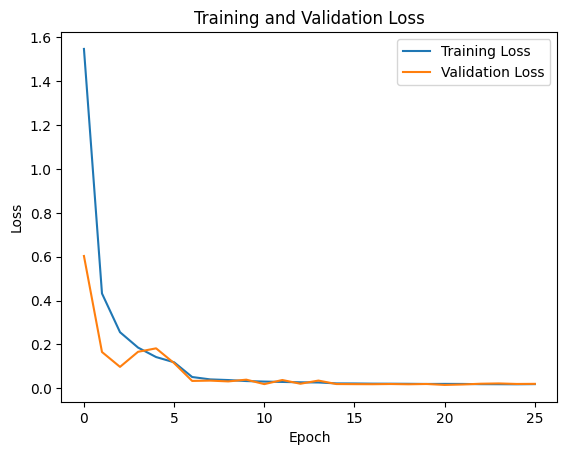

In [46]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()
